Using device: cuda
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.323208,0.231942,0.908500,0.909897
2,0.180181,0.267262,0.917500,0.916960
3,0.103404,0.322002,0.912500,0.913751


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Evaluation Results: {'eval_loss': 0.26726654171943665, 'eval_accuracy': 0.9175, 'eval_f1': 0.9169602415702064, 'eval_runtime': 8.9911, 'eval_samples_per_second': 222.442, 'eval_steps_per_second': 13.903, 'epoch': 3.0}


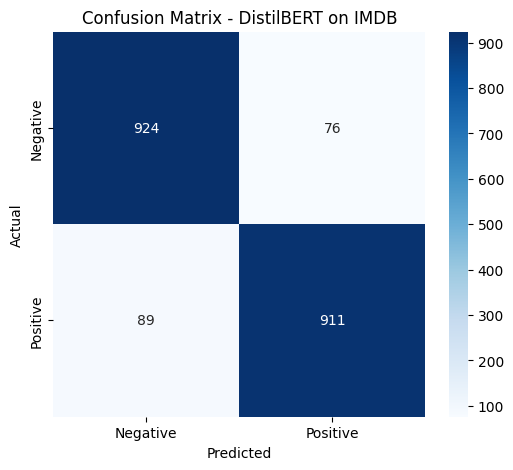


Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.92      0.92      1000
    Positive       0.92      0.91      0.92      1000

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [5]:
# ============================
# Day 9 - Fine-tune DistilBERT
# ============================

!pip install transformers datasets evaluate scikit-learn matplotlib seaborn -q
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
from datasets import load_dataset
import evaluate
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================
# 3. Load Dataset
# ============================
dataset = load_dataset("imdb")
print(dataset)


# ============================
# 4. Tokenization
# ============================
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True, max_length=512)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

# Smaller splits for quick experimentation
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(8000))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(2000))

# ============================
# 5. Model
# ============================
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

# ============================
# 6. Metrics
# ============================
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1_score = f1.compute(predictions=predictions, references=labels)["f1"]
    return {"accuracy": acc, "f1": f1_score}

# ============================
# 7. Training Arguments
# ============================
training_args = TrainingArguments(
    output_dir="./distilbert-imdb",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,           # Start with 3, can increase
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ============================
# 8. Trainer
# ============================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Train the model
trainer.train()

# ============================
# 9. Evaluation
# ============================
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)

# Get predictions for confusion matrix
predictions = trainer.predict(small_eval_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - DistilBERT on IMDB')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=['Negative', 'Positive']))

# ============================
# 10. Save Model
# ============================
trainer.save_model("./distilbert-imdb-finetuned")
tokenizer.save_pretrained("./distilbert-imdb-finetuned")
print("Model saved successfully!")